# **Implementing** : Adversal Deep Hedging :  Learning to Hedge without Price Process Modeling

# The entire implementation will be in three stages


1.   Early setup (black scholes , greeks , data operations ,etc)
2.   Main highlights **Gnerator** and **Hedger**
3.   Testing and comparison of the performance of the Hedger



#1. The early setup

 **Data input and cleaning**

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURATION: SET YOUR FOLDER PATH HERE
# ==========================================
# Replace the path below with the actual path to your folder
DATA_FOLDER = Path(r"C:\Users\ASUS\Desktop\niftydata\upload")

print(f" Scanning directory for files: {DATA_FOLDER}\n")

# Verify if the directory actually exists
if not DATA_FOLDER.exists():
    raise FileNotFoundError(f"The directory '{DATA_FOLDER}' does not exist. Please check your path.")

# Retrieve all files inside the target folder
local_files = [f for f in DATA_FOLDER.iterdir() if f.is_file()]

snapshot_file = None
min_option_file = None
nifty_file = None

# Extension-agnostic mapping logic (adapted for local Path objects)
for f in local_files:
    filename = f.name
    if f.suffix.lower() == '.txt':
        if "snap" in filename.lower() or "chain" in filename.lower() or "strike" in filename.lower():
            snapshot_file = f
        else:
            if snapshot_file is None: 
                snapshot_file = f
            else: 
                min_option_file = f
    else:
        # Avoid picking up system hidden files (like .DS_Store on Mac or desktop.ini on Windows)
        if not filename.startswith('.'):
            nifty_file = f

# Fallback index mapping if name strings don't carry descriptive tags
if not min_option_file and len(local_files) >= 3:
    txt_files = [f for f in local_files if f.suffix.lower() == '.txt']
    if len(txt_files) >= 2:
        snapshot_file = txt_files[0]
        min_option_file = txt_files[1]

# Displaying final picked paths
print(" Finalized Data Source Assignments:")
print(f" -> Snapshot File:         {snapshot_file.name if snapshot_file else 'NOT FOUND'}")
print(f" -> Continuous Nifty File: {nifty_file.name if nifty_file else 'NOT FOUND'}")
print(f" -> Minute Options Trade:  {min_option_file.name if min_option_file else 'NOT FOUND'}")

# Example of how you will load these locally later in your code:
# df_snapshot = pd.read_csv(snapshot_file, sep='\t') # (Adjust delimiter if needed)



 Scanning directory for files: C:\Users\ASUS\Desktop\niftydata\upload

 Finalized Data Source Assignments:
 -> Snapshot File:         snapshot.txt
 -> Continuous Nifty File: niftyup
 -> Minute Options Trade:  upn502017.txt


In [4]:
df_feb05 = pd.read_csv(snapshot_file, names=['symbol', 'date', 'time', 'open', 'high', 'low', 'close', 'volume'])

# Normalize string layout formatting for dates
df_feb05['date_clean'] = df_feb05['date'].astype(str).str.replace('/', '-')
df_feb05['observation_datetime'] = pd.to_datetime(df_feb05['date_clean'] + ' ' + df_feb05['time'].astype(str))

# Parse clean text layout symbols (e.g., "CE 9600")
def parse_symbol(symbol):
    option_type = None
    strike = None
    parts = str(symbol).split()
    if len(parts) >= 2:
        option_type = 'call' if 'CE' in parts else 'put' if 'PE' in parts else None
        strike = float(parts[1])
    return strike, option_type

df_feb05[['strike', 'option_type']] = df_feb05['symbol'].apply(lambda x: pd.Series(parse_symbol(x)))
options_df = df_feb05.dropna(subset=['strike', 'option_type']).copy()
options_df['last_trade_price'] = options_df['close']

# Set absolute contract expiry anchor timeline bounds
expiration_date = pd.to_datetime('2017-07-31 15:30:00')
options_df['T'] = (expiration_date - options_df['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)
r = 0.065  # 6.5% standard benchmark baseline risk-free rate

# 2. Parse File 2: Timezone offset tracking on extensionless Nifty file
df_nifty = pd.read_csv(nifty_file, names=['raw_time', 'open', 'high', 'low', 'close', 'volume'])

# IMPROVISED: Strip out the "+05:30" string fragment to ensure timeline matching
df_nifty['time_clean'] = df_nifty['raw_time'].str.split('+').str[0]
df_nifty['timestamp'] = pd.to_datetime(df_nifty['time_clean'], format='%Y-%m-%d %H:%M:%S')

# Execute chronological lookback join tracking
options_df = options_df.sort_values('observation_datetime')
df_nifty_sorted = df_nifty.sort_values('timestamp')

options_df = pd.merge_asof(
    options_df,
    df_nifty_sorted[['timestamp', 'close']].rename(columns={'close': 'S'}),
    left_on='observation_datetime',
    right_on='timestamp',
    direction='backward'
)

print(f" Data processed. Successfully mapped {len(options_df)} options trades alongside active spots.")
display(options_df[['symbol', 'observation_datetime', 'S', 'last_trade_price']].head())



 Data processed. Successfully mapped 18 options trades alongside active spots.


,symbol,observation_datetime,S,last_trade_price
0,CE 10100,2017-06-14 09:15:00,9615.3,10.85
1,CE 9500,2017-06-14 09:15:00,9615.3,212.20
2,CE 9600,2017-06-14 09:15:00,9615.3,151.05
3,CE 9700,2017-06-14 09:15:00,9615.3,99.95
4,CE 9800,2017-06-14 09:15:00,9615.3,60.40


**Black** **Scholes**

In [5]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            return max(0, S - K), 0, 0, 0
        else:
            return max(0, K - S), 0, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

print("Black-Scholes function defined.")

Black-Scholes function defined.


Implied Volatility

In [6]:
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100, verbose=False):
    low_vol = 0.001
    high_vol = 5.0 # Max reasonable volatility

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2

        if verbose:
            print(f"Iteration {i+1}: low_vol={low_vol:.4f}, high_vol={high_vol:.4f}, mid_vol={mid_vol:.4f}")

        if mid_vol < 1e-6: # Avoid division by zero or extremely small sigma
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if verbose:
            print(f"  BS Price: {bs_price:.2f}, Observed Price: {observed_price:.2f}, Diff: {bs_price - observed_price:.2f}")

        # Handle cases where BS price is very close to observed price
        if abs(bs_price - observed_price) < tol:
            return mid_vol

        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol

        if (high_vol - low_vol) < tol:
            if verbose:
                print(f"Converged within tolerance at iteration {i+1}.")
            return mid_vol # Converged within tolerance

    if verbose:
        print("Max iterations reached, returning best guess.")
    return mid_vol # Return the best guess if max_iter reached

print("Implied Volatility solver defined.")

Implied Volatility solver defined.


implied volatility for all options

The Greeks

Greek plots

Iteration 1: low_vol=0.0010, high_vol=5.0000, mid_vol=2.5005
  BS Price: 3210.06, Observed Price: 10.85, Diff: 3199.21
Iteration 2: low_vol=0.0010, high_vol=2.5005, mid_vol=1.2508
  BS Price: 1553.98, Observed Price: 10.85, Diff: 1543.13
Iteration 3: low_vol=0.0010, high_vol=1.2508, mid_vol=0.6259
  BS Price: 693.98, Observed Price: 10.85, Diff: 683.13
Iteration 4: low_vol=0.0010, high_vol=0.6259, mid_vol=0.3134
  BS Price: 269.70, Observed Price: 10.85, Diff: 258.85
Iteration 5: low_vol=0.0010, high_vol=0.3134, mid_vol=0.1572
  BS Price: 76.51, Observed Price: 10.85, Diff: 65.66
Iteration 6: low_vol=0.0010, high_vol=0.1572, mid_vol=0.0791
  BS Price: 9.52, Observed Price: 10.85, Diff: -1.33
Iteration 7: low_vol=0.0791, high_vol=0.1572, mid_vol=0.1182
  BS Price: 37.53, Observed Price: 10.85, Diff: 26.68
Iteration 8: low_vol=0.0791, high_vol=0.1182, mid_vol=0.0986
  BS Price: 21.66, Observed Price: 10.85, Diff: 10.81
Iteration 9: low_vol=0.0791, high_vol=0.0986, mid_vol=0.0889
  BS Pri

,symbol,strike,option_type,last_trade_price,implied_volatility
0,CE 10100,10100.0,call,10.85,0.081655
1,CE 9500,9500.0,call,212.20,0.058238
2,CE 9600,9600.0,call,151.05,0.069698
3,CE 9700,9700.0,call,99.95,0.073665
4,CE 9800,9800.0,call,60.40,0.074790


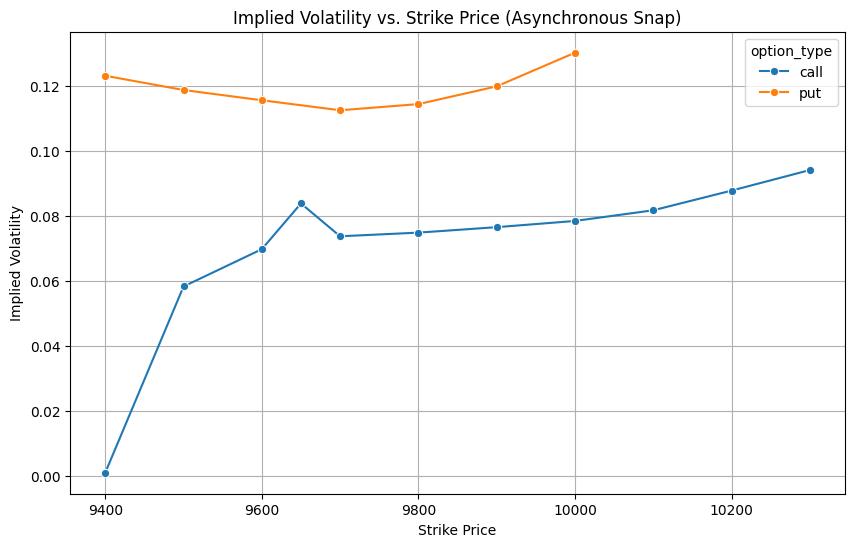

,symbol,strike,option_type,last_trade_price,implied_volatility,delta,gamma,theta
0,CE 10100,10100.0,call,10.85,0.081655,0.084824,0.000550,-221.868504
1,CE 9500,9500.0,call,212.20,0.058238,0.838381,0.001216,-700.824372
2,CE 9600,9600.0,call,151.05,0.069698,0.659653,0.001521,-743.920545
3,CE 9700,9700.0,call,99.95,0.073665,0.499868,0.001566,-698.699663
4,CE 9800,9800.0,call,60.40,0.074790,0.351540,0.001434,-586.622227


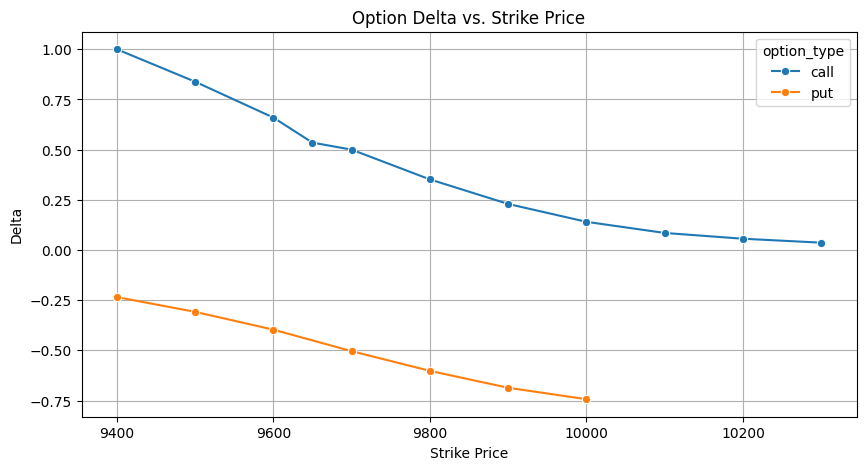

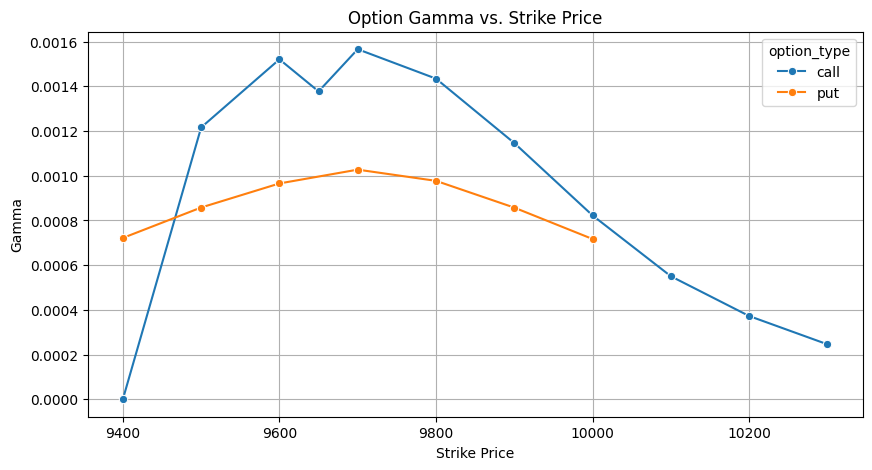

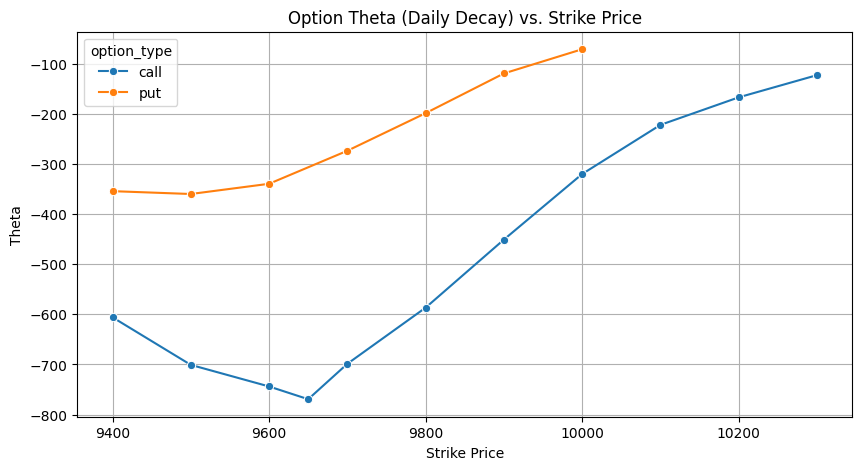

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

# Check if the dynamically merged spot column is available in our dataset
if 'S' in options_df.columns and not options_df['S'].isna().all():
    options_df['implied_volatility'] = options_df.apply(
        lambda row: implied_volatility(row['last_trade_price'], row['S'], row['strike'], row['T'], r, row['option_type'], verbose=True)
        if row['T'] > 0 and not pd.isna(row['S']) else 0.0, axis=1
    )
else:
    options_df['implied_volatility'] = np.nan
    print("Cannot calculate implied volatility as dynamic future price (S) is not available.")

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility']].head())

# --- Plot 1: Implied Volatility Plot -----
plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike', y='implied_volatility', hue='option_type', marker='o')
plt.title('Implied Volatility vs. Strike Price (Asynchronous Snap)')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.grid(True)
plt.show()

# --- Process Greeks Calculations ---
if 'S' in options_df.columns and not options_df['S'].isna().all():
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = options_df.apply(
        lambda row:
            pd.Series(black_scholes(
                row['S'], row['strike'], row['T'], r, row['implied_volatility'], row['option_type']
            ))
        if row['T'] > 0 and not pd.isna(row['implied_volatility']) and not pd.isna(row['S'])
        else pd.Series([np.nan, np.nan, np.nan, np.nan]), axis=1
    )
else:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = np.nan
    print("Cannot calculate Greeks as dynamic future price (S) is not available.")

display(options_df[['symbol', 'strike', 'option_type', 'last_trade_price', 'implied_volatility', 'delta', 'gamma', 'theta']].head())

# --- Plot 2: Isolated Delta vs Strike Price -----
plt.figure(figsize=(10, 5))
sns.lineplot(data=options_df, x='strike', y='delta', hue='option_type', marker='o')
plt.title('Option Delta vs. Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Delta')
plt.grid(True)
plt.show()

# --- Plot 3: Isolated Gamma vs Strike Price -----
plt.figure(figsize=(10, 5))
sns.lineplot(data=options_df, x='strike', y='gamma', hue='option_type', marker='o')
plt.title('Option Gamma vs. Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Gamma')
plt.grid(True)
plt.show()

# --- Plot 4: Isolated Theta vs Strike Price -----
plt.figure(figsize=(10, 5))
sns.lineplot(data=options_df, x='strike', y='theta', hue='option_type', marker='o')
plt.title('Option Theta (Daily Decay) vs. Strike Price')
plt.xlabel('Strike Price')
plt.ylabel('Theta')
plt.grid(True)
plt.show()


## **Implementing Delta neutral stratgy**

In [8]:

print(" Launching Dynamic Delta Hedging Matrix Simulation Engine...")

# Define target tracking contract parameter coordinates based on your 2017 text strings
target_strike = 9800.0  # Modified from 2570000 to match realistic 2017 Nifty ranges (e.g. 9600)
target_option_type = 'call'
target_symbol_contains = 'CE 9800'  # Text code variant matching row symbols

K = target_strike
r = 0.065  # 6.5% standard benchmark execution rate

# Load File 3 (Minute Option tracking file)
df_options_min_raw = pd.read_csv(min_option_file, names=['symbol', 'date', 'time', 'open', 'high', 'low', 'close', 'volume'])

# Clean and normalize timestamps
df_options_min_raw['date_clean'] = df_options_min_raw['date'].astype(str).str.replace('/', '-')
df_options_min_raw['observation_datetime'] = pd.to_datetime(df_options_min_raw['date_clean'] + ' ' + df_options_min_raw['time'].astype(str))

# Isolate target options sequence frames
option_prices_df = df_options_min_raw[df_options_min_raw['symbol'].astype(str).str.contains(target_symbol_contains)].copy()

# Synchronize time steps against Nifty tracking metrics with stripped offsets
future_prices_df = df_nifty_sorted[['timestamp', 'close']].rename(columns={'timestamp': 'observation_datetime', 'close': 'last_trade_price_fut'}).copy()

# Merge step ensuring seamless chronological row alignments
# Merge step ensuring seamless chronological row alignments
time_series_merged = pd.merge(future_prices_df, option_prices_df, on='observation_datetime')
time_series_merged = time_series_merged.sort_values('observation_datetime').reset_index(drop=True)

#   DEBUG CHECK HERE
if time_series_merged.empty:
    print("\n ERROR: time_series_merged is EMPTY!")
    print(f"Check if '{target_symbol_contains}' exists in your options file.")
    print("Available symbols sample:", df_options_min_raw['symbol'].unique()[:5])
    import sys; sys.exit() # Safely stop execution


# Calculate annual time breakdown elements remaining
time_series_merged['T'] = (expiration_date - time_series_merged['observation_datetime']).dt.total_seconds() / (365.25 * 24 * 3600)

# Initialize strategy ledger tracking parameters
cumulative_trading_pnl_iv_hedge = 0.0
delta_history_iv = []
iv_history = []
asset_price_history_iv = []

print(f"\nProcessing simulation arrays down {len(time_series_merged)} synchronized timeline slices...")

# Run trading ledger simulation adjustments
for i in range(len(time_series_merged) - 1):
    S_ti = time_series_merged['last_trade_price_fut'].iloc[i]
    observed_option_price_ti = time_series_merged['close'].iloc[i] # Uses 'close' from your options file column array
    T_ti = time_series_merged['T'].iloc[i]

    # Calculate minute-specific Implied Volatility
    current_iv = implied_volatility(observed_option_price_ti, S_ti, K, T_ti, r, target_option_type)

    # Fallback guard constraints processing
    if pd.isna(current_iv) or current_iv <= 0:
        current_iv = iv_history[-1] if iv_history else 0.25  # Realigned default standard marker volatility level

    # Evaluate dynamic localized position Delta
    _, current_delta, _, _ = black_scholes(S_ti, K, T_ti, r, current_iv, target_option_type)

    delta_history_iv.append(current_delta)
    iv_history.append(current_iv)
    asset_price_history_iv.append(S_ti)

    # Fetch next sequence point asset calculation boundary coordinates
    S_ti_plus_1 = time_series_merged['last_trade_price_fut'].iloc[i+1]

    # Increment running interval hedge portfolio trading ledger performance matrix metrics
    pnl_this_interval = current_delta * (S_ti_plus_1 - S_ti)
    cumulative_trading_pnl_iv_hedge += pnl_this_interval

# Calculate terminal contract value matrices at delivery expiry bounds
S_T = time_series_merged['last_trade_price_fut'].iloc[-1]
option_payoff_at_expiry = max(0.0, S_T - K) if target_option_type == 'call' else max(0.0, K - S_T)

# Aggregate strategy bottom-line performance yield summaries
PL_T_iv_hedging = -option_payoff_at_expiry + cumulative_trading_pnl_iv_hedge

print(f"\n --- DELTA HEDGING BACKTEST RESULTS ({target_symbol_contains}) ---")
print(f" Final Underlying Price (S_T):                     {S_T:.2f}")
print(f" Short Option Contract Payoff at Expiry (-Z_T):     {-option_payoff_at_expiry:.2f}")
print(f" Cumulative Hedging Portfolio Delta Trade P&L:      {cumulative_trading_pnl_iv_hedge:.2f}")
print(f" Total Net Strategy Performance P&L (PL_T):        {PL_T_iv_hedging:.2f}")


 Launching Dynamic Delta Hedging Matrix Simulation Engine...

Processing simulation arrays down 11323 synchronized timeline slices...

 --- DELTA HEDGING BACKTEST RESULTS (CE 9800) ---
 Final Underlying Price (S_T):                     10020.60
 Short Option Contract Payoff at Expiry (-Z_T):     -220.60
 Cumulative Hedging Portfolio Delta Trade P&L:      198.32
 Total Net Strategy Performance P&L (PL_T):        -22.28


# 2. Implementing Generator and Hedger

The Generator

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

S0 = time_series_merged['last_trade_price_fut'].iloc[0]  # Initial future/spot price from original data
num_steps = len(time_series_merged) - 1                  # Total active minute intervals

# Calculate the total time in years (from start to end of the real data timeline)
time_diff = (time_series_merged['observation_datetime'].iloc[-1] - time_series_merged['observation_datetime'].iloc[0]).total_seconds()
T_total_years = time_diff / (365.25 * 24 * 3600)
dt = T_total_years / num_steps                           # Time increment fraction per step

r = 0.065   # Synced 6.5% standard benchmark risk-free rate for the 2017 environment
mu = r      # Drift rate under risk-neutral measure
sigma = 0.6 # Volatility parameter as specified by the user
num_paths = 100 # Target count for paths matrix array generation

def generate_gbm_path(S0, mu, sigma, dt, num_steps):
    '''Generates a single price path using Geometric Brownian Motion.'''
    prices = np.zeros(num_steps + 1)
    prices[0] = S0
    for i in range(1, num_steps + 1):
        # Z is a standard normal random variable
        Z = np.random.normal(0, 1)
        prices[i] = prices[i-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return prices

# Generate multiple price paths
np.random.seed(42) # for reproducibility
synthetic_price_paths = []
for _ in range(num_paths):
    path = generate_gbm_path(S0, mu, sigma, dt, num_steps)
    synthetic_price_paths.append(path)

print(f"Generated {num_paths} synthetic price paths, each with {num_steps + 1} points.")
print(f"Initial price (S0): {S0:.2f}")
print(f"Drift (mu): {mu}")
print(f"Volatility (sigma): {sigma}")
print(f"Time step (dt) in years: {dt:.6f}")

Generated 100 synthetic price paths, each with 11323 points.
Initial price (S0): 9615.30
Drift (mu): 0.065
Volatility (sigma): 0.6
Time step (dt) in years: 0.000010


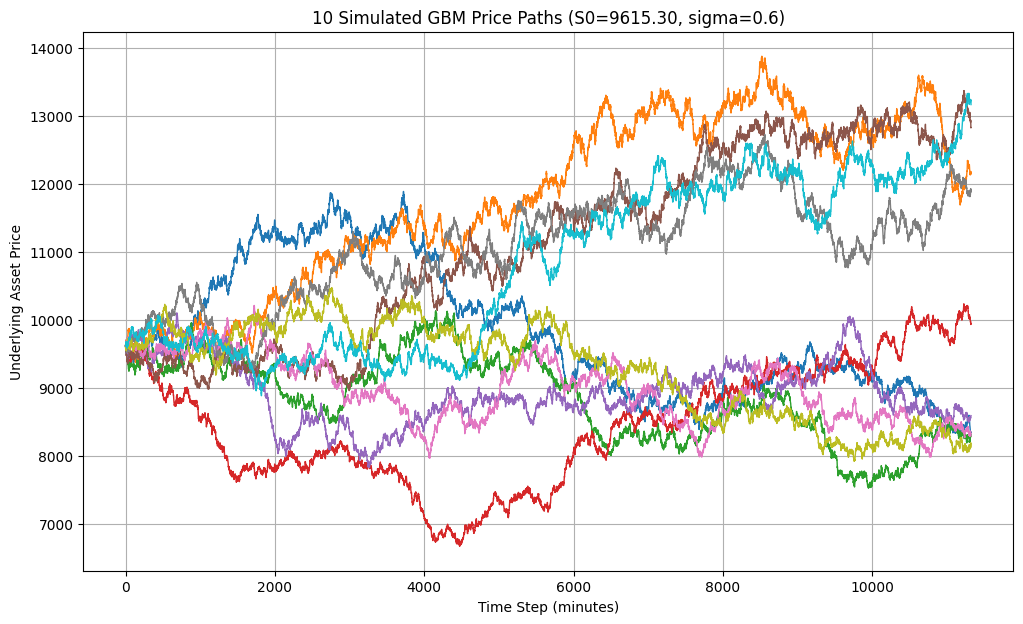

In [10]:
## vizualization for some gbm series ---
plt.figure(figsize=(12, 7))
for i in range(min(10, num_paths)): # Plot first 10 paths for clarity
    plt.plot(synthetic_price_paths[i], lw=1)
plt.title(f'{min(10, num_paths)} Simulated GBM Price Paths (S0={S0:.2f}, sigma={sigma})')
plt.xlabel('Time Step (minutes)')
plt.ylabel('Underlying Asset Price')
plt.grid(True)
plt.show()

Calculating black scholes , greeks ,iv for generated series

In [11]:
# Option parameters for Black-Scholes calculation (same as the real data option)
option_K = target_strike # Strike price (from previous real data analysis)
option_r = r             # Risk-free rate (from previous real data analysis)
option_type = 'call'     # Target option type

# We will use a constant volatility for these theoretical calculations,
# as the GBM paths were generated with a constant sigma (0.6). We'll use this.
theoretical_sigma = sigma # Use the same sigma as GBM generation (0.6)

# Prepare lists to store calculated Black-Scholes prices and deltas for all paths
all_bs_prices = []
all_bs_deltas = []

print(f"Calculating Black-Scholes prices and deltas for {num_paths} paths...")

# Iterate through each synthetic price path
for path_idx, s_path in enumerate(synthetic_price_paths):
    bs_prices_for_path = []
    bs_deltas_for_path = []

    # Iterate through each time step in the path
    for t_step in range(num_steps + 1):
        S_t = s_path[t_step]

        # Calculate time to expiration for this step
        # T decreases over time. T_total_years is the initial total time.
        # The remaining time is T_total_years - (t_step * dt)
        T_remaining = T_total_years - (t_step * dt)

        # Ensure T_remaining is not negative due to floating point precision at expiry
        if T_remaining < 0: T_remaining = 0

        # Calculate Black-Scholes price and delta
        price, delta, _, _ = black_scholes(S_t, option_K, T_remaining, option_r, theoretical_sigma, option_type)

        bs_prices_for_path.append(price)
        bs_deltas_for_path.append(delta)

    all_bs_prices.append(np.array(bs_prices_for_path))
    all_bs_deltas.append(np.array(bs_deltas_for_path))

# Convert to numpy arrays for easier manipulation
all_bs_prices = np.array(all_bs_prices)
all_bs_deltas = np.array(all_bs_deltas)

print(f"Finished calculating BS prices and deltas. Shape: {all_bs_prices.shape}")

# Display a sample (e.g., first path's prices and deltas)
print("\nSample Black-Scholes Prices for the first path (first 5 and last 5):")
print(all_bs_prices[0, :5])
print(all_bs_prices[0, -5:])

print("\nSample Black-Scholes Deltas for the first path (first 5 and last 5):")
print(all_bs_deltas[0, :5])
print(all_bs_deltas[0, -5:])

Calculating Black-Scholes prices and deltas for 100 paths...
Finished calculating BS prices and deltas. Shape: (100, 11323)

Sample Black-Scholes Prices for the first path (first 5 and last 5):
[741.60239708 746.38248249 744.99362027 751.26466373 766.21715458]
[0. 0. 0. 0. 0.]

Sample Black-Scholes Deltas for the first path (first 5 and last 5):
[0.51929466 0.52114826 0.52062419 0.52304289 0.52873585]
[0. 0. 0. 0. 0.]


**Split Data into Training and Test Sets**

We will now split the generated synthetic price paths, their corresponding Black-Scholes prices, and deltas into training and testing datasets. This is crucial for evaluating the performance of our Deep Hedger on unseen data.

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
# Convert lists of arrays to a single numpy array if not already
synthetic_price_paths_array = np.array(synthetic_price_paths)

# Define the split ratio (e.g., 80% for training, 20% for testing)
test_size_ratio = 0.2

# Split the synthetic price paths
S_train, S_test = train_test_split(synthetic_price_paths_array, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes prices
BS_prices_train, BS_prices_test = train_test_split(all_bs_prices, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes deltas
BS_deltas_train, BS_deltas_test = train_test_split(all_bs_deltas, test_size=test_size_ratio, random_state=42)

print(f"Training set size: {len(S_train)} paths")
print(f"Test set size: {len(S_test)} paths")

print(f"Shape of S_train: {S_train.shape}")
print(f"Shape of BS_deltas_train: {BS_deltas_train.shape}")

Training set size: 80 paths
Test set size: 20 paths
Shape of S_train: (80, 11323)
Shape of BS_deltas_train: (80, 11323)


Defining the Hedger

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Concatenate, SimpleRNN, Dense

class DeepHedgerSimpleRNN(Model):
    def __init__(self, num_rnn_units=32, **kwargs):
        super(DeepHedgerSimpleRNN, self).__init__(**kwargs)
        # 1. Instantiate the processing components
        self.concat = Concatenate(axis=-1)

        # return_sequences=True tells the SimpleRNN to evaluate every time step sequentially
        self.rnn_layer = SimpleRNN(
            num_rnn_units,
            return_sequences=True,
            activation='tanh',
            name='rnn_memory_core'
        )

        # Final projection layer to map the hidden recurrent states to our hedging position
        self.dense_output = Dense(1, activation='tanh', name='delta_t_output')

    def call(self, inputs):
        # 2. Safely unpacks [batch_S_seq, batch_BS_delta_seq] passed from your loop
        s_input, bs_delta_input = inputs

        # 3. Combine the asset price and BS delta along the final feature dimension
        # Shape change: (batch, steps, 1) + (batch, steps, 1) -> (batch, steps, 2)
        combined = self.concat([s_input, bs_delta_input])

        # 4. Process the path through the standard SimpleRNN layer
        # Natively loops through each time step, tracking historical changes
        rnn_out = self.rnn_layer(combined)

        # 5. Output a sequence of deltas matching the exact format expected by your loop
        # Returns shape: (batch_size, num_time_steps, 1)
        return self.dense_output(rnn_out)

# --- Instantiate the Subclassed Model ---
# This single object is completely robust against list tracer bugs during GradientTape passes
deep_hedger_rnn = DeepHedgerSimpleRNN(num_rnn_units=32)

print("Model successfully initialized and synced with your array-based pipeline!")


Model successfully initialized and synced with your array-based pipeline!


 **P&L Calculation and CVaR LossFunction**

In [18]:
# Assuming option_K, r, option_type, dt are already defined globally or passed
# target_strike, r, option_type, dt

@tf.function
def calculate_pnl(S_path_batch, deltas_batch, K, r_tf, option_type_str):
    """
    Calculates the P&L for a batch of price paths and corresponding delta hedges.

    Args:
        S_path_batch (tf.Tensor): Batch of underlying price paths (batch_size, num_steps + 1).
        deltas_batch (tf.Tensor): Batch of delta hedges (batch_size, num_steps + 1).
                                 deltas_batch[..., t] is the delta held from t to t+1.
        K (tf.Tensor): Strike price.
        r_tf (tf.Tensor): Risk-free rate.
        option_type_str (tf.Tensor): String tensor indicating 'call' or 'put'.

    Returns:
        tf.Tensor: A tensor of P&L values for each path in the batch (batch_size,).
    """
    # Ensure tensors are float32 for consistency
    S_path_batch = tf.cast(S_path_batch, tf.float32)
    deltas_batch = tf.cast(deltas_batch, tf.float32)
    K = tf.cast(K, tf.float32)
    r_tf = tf.cast(r_tf, tf.float32)

    # Reshape deltas_batch to (batch_size, num_steps + 1) if it's (batch_size, num_steps + 1, 1)
    if len(deltas_batch.shape) == 3: # Handle case where delta_output is (batch_size, timesteps, 1)
        deltas_batch = tf.squeeze(deltas_batch, axis=-1)

    # S_t is S_path_batch[:, :-1]
    # S_{t+1} is S_path_batch[:, 1:]
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]

    # Delta position at time t is held from t to t+1. So we use deltas_batch[:, :-1] (or just deltas_batch) for trading P&L
    # The last delta in deltas_batch is the delta at expiry, which contributes to the final option value, not trading PnL
    # This matches the (delta . S)_T definition in the paper where delta_ti is for (S_{ti+1} - S_ti)
    trading_pnl_per_interval = deltas_batch[:, :-1] * price_changes
    cumulative_trading_pnl = tf.reduce_sum(trading_pnl_per_interval, axis=1)

    # Option payoff at expiry (Z_T)
    S_T = S_path_batch[:, -1] # Final underlying price

    # Check option type using tf.strings.equal
    is_call = tf.math.equal(option_type_str, tf.constant('call'))

    option_payoff_at_expiry_call = tf.maximum(0.0, S_T - K)
    option_payoff_at_expiry_put = tf.maximum(0.0, K - S_T)

    # Use tf.where to select based on option type
    option_payoff_at_expiry = tf.where(
        tf.cast(is_call, tf.bool),
        option_payoff_at_expiry_call,
        option_payoff_at_expiry_put
    )

    # Total P&L: -Z_T + cumulative_trading_pnl (no transaction costs)
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl

    return total_pnl

@tf.function
def cvar_loss(pnl_values, alpha=0.05):
    """
    Calculates the CVaR (Conditional Value at Risk) loss for a batch of P&L values.
    CVaR is the expected loss in the worst 'alpha' percentile.

    Args:
        pnl_values (tf.Tensor): A batch of P&L values (batch_size,).
        alpha (float): The significance level for CVaR (e.g., 0.05 for 5%).

    Returns:
        tf.Tensor: The CVaR loss (scalar).
    """
    # Sort P&L values in ascending order (from worst loss to best profit)
    sorted_pnl = tf.sort(pnl_values)

    # Calculate the index for VaR_alpha (worst 'alpha' percentage)
    num_samples = tf.cast(tf.shape(sorted_pnl)[0], tf.float32)
    cvar_index = tf.cast(tf.floor(num_samples * alpha), tf.int32)

    # Select the worst 'alpha' percentile of P&L values
    # Note: tf.slice is exclusive of the end index, so we need to go up to cvar_index
    worst_pnl_values = sorted_pnl[:cvar_index + 1] # Include up to the alpha-th percentile

    # CVaR is the negative of the average of these worst P&L values
    # We want to minimize the loss, so we minimize -CVaR or maximize CVaR.
    # Conventionally, CVaR is expressed as a positive loss, so we take the negative mean of P&L
    # PNL is profit, so minimizing average PNL means making profits smaller.
    # If PNL is negative (a loss), then -PNL is positive, and minimizing it means minimizing the loss.
    # So, CVaR loss will be -mean(worst_pnl_values)
    cvar_value = -tf.reduce_mean(worst_pnl_values)

    return cvar_value

print("TensorFlow-compatible P&L calculation and CVaR loss functions defined.")

TensorFlow-compatible P&L calculation and CVaR loss functions defined.


Custom training loop

In [19]:

import tensorflow as tf

# Setup optimizer and execution hyperparameters
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
epochs = 10
batch_size = 32

num_train_paths = S_train.shape[0]

# Convert numpy training arrays to efficient pipeline sliced TF Datasets
train_dataset = tf.data.Dataset.from_tensor_slices(
    (S_train, BS_deltas_train)
).shuffle(num_train_paths).batch(batch_size)

print(f" Starting True RNN Model Training for {epochs} epochs...")

for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()

    for step, (batch_S_paths, batch_BS_deltas) in enumerate(train_dataset):
        with tf.GradientTape() as tape:

            #  Add a trailing feature dimension to match the sequence format (batch_size, timesteps, 1)
            batch_S_seq = tf.expand_dims(batch_S_paths, axis=-1)
            batch_BS_delta_seq = tf.expand_dims(batch_BS_deltas, axis=-1)

            # ---  RNN SEQUENCE INFERENCE (ONE-LINE FULL PATH EVALUATION) ---
            # The RNN natively loops over time steps under the hood and tracks past hedge memory!
            final_predicted_deltas_seq = deep_hedger_rnn([batch_S_seq, batch_BS_delta_seq])

            # Squeeze output from (batch_size, num_time_steps, 1) -> (batch_size, num_time_steps)
            final_predicted_deltas_squeezed = tf.squeeze(final_predicted_deltas_seq, axis=-1)

            # Calculate the cumulative batch portfolio P&L vectors
            pnl_values = calculate_pnl(
                batch_S_paths,
                final_predicted_deltas_squeezed,
                tf.constant(option_K, dtype=tf.float32),
                tf.constant(option_r, dtype=tf.float32),
                tf.constant(option_type, dtype=tf.string)
            )

            # Evaluate strategy performance against the tail CVaR loss objective function
            loss = cvar_loss(pnl_values, alpha=0.05)

        # Apply backing optimization updates across trainable variables graph paths
        gradients = tape.gradient(loss, deep_hedger_rnn.trainable_variables)
        optimizer.apply_gradients(zip(gradients, deep_hedger_rnn.trainable_variables))

        epoch_loss_avg.update_state(loss)

    # Print loss updates per epoch milestones
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f" -> Epoch {epoch+1:02d}/{epochs}, Calculated Expected Tail CVaR Loss: {epoch_loss_avg.result():.4f}")

print("\n Simple RNN Deep Hedging Model Training Cycle Successfully Completed.")


 Starting True RNN Model Training for 10 epochs...
 -> Epoch 01/10, Calculated Expected Tail CVaR Loss: 2672.5803
 -> Epoch 10/10, Calculated Expected Tail CVaR Loss: 1759.1349

 Simple RNN Deep Hedging Model Training Cycle Successfully Completed.


# 3. Model evaluation and comparison

In [20]:

import tensorflow as tf
import numpy as np

# Helper function rewritten to leverage full sequence matrix execution
@tf.function
def predict_deltas_rnn(model, S_paths, BS_deltas_input):
    """
    Leverages the recurrent layer properties to extract full-horizon
    delta sequences simultaneously without manual looping blocks.
    """
    # Reshape input to append a tracking feature dimension (batch_size, timesteps, 1)
    S_seq = tf.expand_dims(tf.cast(S_paths, tf.float32), axis=-1)
    BS_delta_seq = tf.expand_dims(tf.cast(BS_deltas_input, tf.float32), axis=-1)

    # Process full batch matrix path track calculations instantly
    predicted_seq = model([S_seq, BS_delta_seq])

    # Squeeze feature index out returning dimensions: (batch_size, timesteps)
    return tf.squeeze(predicted_seq, axis=-1)

print(" Calculating P&L for Deep Hedger on Train Set...")
# Deep Hedger P&L on Train Set
dh_predicted_deltas_train = predict_deltas_rnn(deep_hedger_rnn, S_train, BS_deltas_train)
dh_pnl_train = calculate_pnl(
    S_train,
    dh_predicted_deltas_train,
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy() # Convert to numpy for analysis

print(" Calculating P&L for Deep Hedger on Test Set...")
# Deep Hedger P&L on Test Set
dh_predicted_deltas_test = predict_deltas_rnn(deep_hedger_rnn, S_test, BS_deltas_test)
dh_pnl_test = calculate_pnl(
    S_test,
    dh_predicted_deltas_test,
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy() # Convert to numpy for analysis

print(" Deep Hedger P&L calculated via parallel sequence execution.")


 Calculating P&L for Deep Hedger on Train Set...
 Calculating P&L for Deep Hedger on Test Set...
 Deep Hedger P&L calculated via parallel sequence execution.


In [21]:
import tensorflow as tf
import numpy as np

print("Calculating P&L for Black-Scholes Delta Hedging on Train Set...")
# Vectorised evaluation across training dataset matrix steps (No loops!)
bs_pnl_train = calculate_pnl(
    tf.constant(S_train, dtype=tf.float32),
    tf.constant(BS_deltas_train, dtype=tf.float32),
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy()

print("Calculating P&L for Black-Scholes Delta Hedging on Test Set...")
# Vectorised evaluation across testing dataset matrix steps (No loops!)
bs_pnl_test = calculate_pnl(
    tf.constant(S_test, dtype=tf.float32),
    tf.constant(BS_deltas_test, dtype=tf.float32),
    tf.constant(option_K, dtype=tf.float32),
    tf.constant(option_r, dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy()

print(" Black-Scholes Delta Hedging P&L calculated for train and test sets.")


Calculating P&L for Black-Scholes Delta Hedging on Train Set...
Calculating P&L for Black-Scholes Delta Hedging on Test Set...
 Black-Scholes Delta Hedging P&L calculated for train and test sets.


In [22]:
import numpy as np
import tensorflow as tf

def calculate_var(pnl_values, alpha=0.05):
    """
    Calculates Value at Risk (VaR) for a given set of P&L values.
    """
    pnl_values_sorted = np.sort(pnl_values)
    index = int(np.floor(len(pnl_values_sorted) * alpha))
    return pnl_values_sorted[index]

def calculate_cvar_numpy(pnl_values, alpha=0.05):
    """
    Convert the tf.function cvar_loss to a numpy-compatible function for reporting
    """
    return cvar_loss(tf.constant(pnl_values, dtype=tf.float32), alpha=alpha).numpy()

print(" VaR and NumPy-compatible CVaR calculation functions defined.")

 VaR and NumPy-compatible CVaR calculation functions defined.


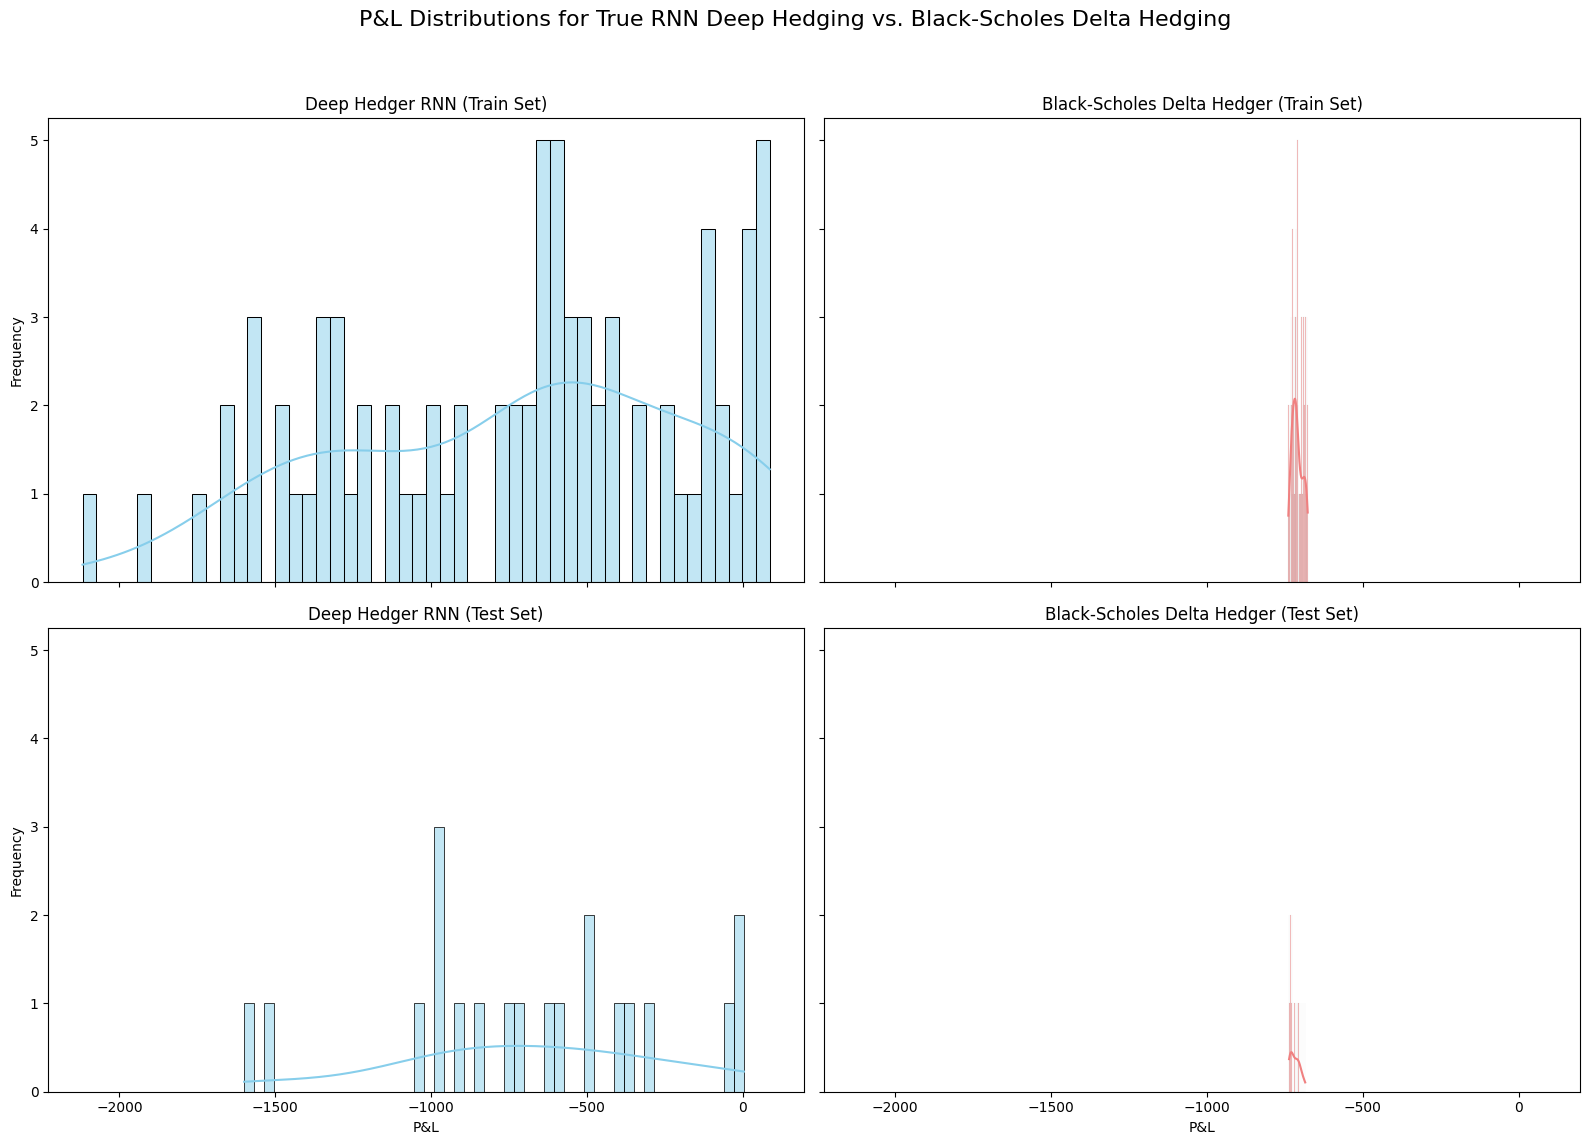


--- Hedging Performance Metrics (alpha = 5%) ---

Deep Hedger RNN (Train Set):
  Mean P&L: -743.05
  Std Dev P&L: 561.59
  VaR (5%): -1637.19
  CVaR (5%): 1815.97

Black-Scholes Delta Hedger (Train Set):
  Mean P&L: -709.58
  Std Dev P&L: 17.68
  VaR (5%): -734.47
  CVaR (5%): 736.66

Deep Hedger RNN (Test Set):
  Mean P&L: -683.28
  Std Dev P&L: 432.75
  VaR (5%): -1505.64
  CVaR (5%): 1552.87

Black-Scholes Delta Hedger (Test Set):
  Mean P&L: -717.52
  Std Dev P&L: 15.27
  VaR (5%): -735.88
  CVaR (5%): 736.20


In [23]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

alph_level = 0.05

# --- Plotting P&L Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('P&L Distributions for True RNN Deep Hedging vs. Black-Scholes Delta Hedging', fontsize=16)

sns.histplot(dh_pnl_train, bins=50, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Deep Hedger RNN (Train Set)')
axes[0, 0].set_xlabel('P&L')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(bs_pnl_train, bins=50, kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Black-Scholes Delta Hedger (Train Set)')
axes[0, 1].set_xlabel('P&L')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(dh_pnl_test, bins=50, kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Deep Hedger RNN (Test Set)')
axes[1, 0].set_xlabel('P&L')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(bs_pnl_test, bins=50, kde=True, ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Black-Scholes Delta Hedger (Test Set)')
axes[1, 1].set_xlabel('P&L')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Reporting VaR and CVaR ---
print(f"\n--- Hedging Performance Metrics (alpha = {alph_level:.0%}) ---")

# Deep Hedger Train
mean_pnl_dh_train = np.mean(dh_pnl_train)
std_pnl_dh_train = np.std(dh_pnl_train)
var_dh_train = calculate_var(dh_pnl_train, alpha=alph_level)
cvar_dh_train = calculate_cvar_numpy(dh_pnl_train, alpha=alph_level)
print(f"\nDeep Hedger RNN (Train Set):\n  Mean P&L: {mean_pnl_dh_train:.2f}\n  Std Dev P&L: {std_pnl_dh_train:.2f}\n  VaR ({alph_level:.0%}): {var_dh_train:.2f}\n  CVaR ({alph_level:.0%}): {cvar_dh_train:.2f}")

# Black-Scholes Hedger Train
mean_pnl_bs_train = np.mean(bs_pnl_train)
std_pnl_bs_train = np.std(bs_pnl_train)
var_bs_train = calculate_var(bs_pnl_train, alpha=alph_level)
cvar_bs_train = calculate_cvar_numpy(bs_pnl_train, alpha=alph_level)
print(f"\nBlack-Scholes Delta Hedger (Train Set):\n  Mean P&L: {mean_pnl_bs_train:.2f}\n  Std Dev P&L: {std_pnl_bs_train:.2f}\n  VaR ({alph_level:.0%}): {var_bs_train:.2f}\n  CVaR ({alph_level:.0%}): {cvar_bs_train:.2f}")

# Deep Hedger Test
mean_pnl_dh_test = np.mean(dh_pnl_test)
std_pnl_dh_test = np.std(dh_pnl_test)
var_dh_test = calculate_var(dh_pnl_test, alpha=alph_level)
cvar_dh_test = calculate_cvar_numpy(dh_pnl_test, alpha=alph_level)
print(f"\nDeep Hedger RNN (Test Set):\n  Mean P&L: {mean_pnl_dh_test:.2f}\n  Std Dev P&L: {std_pnl_dh_test:.2f}\n  VaR ({alph_level:.0%}): {var_dh_test:.2f}\n  CVaR ({alph_level:.0%}): {cvar_dh_test:.2f}")

# Black-Scholes Hedger Test
mean_pnl_bs_test = np.mean(bs_pnl_test)
std_pnl_bs_test = np.std(bs_pnl_test)
var_bs_test = calculate_var(bs_pnl_test, alpha=alph_level)
cvar_bs_test = calculate_cvar_numpy(bs_pnl_test, alpha=alph_level)
print(f"\nBlack-Scholes Delta Hedger (Test Set):\n  Mean P&L: {mean_pnl_bs_test:.2f}\n  Std Dev P&L: {std_pnl_bs_test:.2f}\n  VaR ({alph_level:.0%}): {var_bs_test:.2f}\n  CVaR ({alph_level:.0%}): {cvar_bs_test:.2f}")
